# Dysarthria / ALS Speech Detection — HuBERT + LoRA (Fixed)
## TORGO Dataset · Colab T4 Safe · All Known Issues Resolved

### Fixes applied
| Issue | Fix |
|---|---|
| `transformers` requires PyTorch >= 2.4 | Pinned `transformers==4.40.2` + `peft==0.10.0` |
| `get_peft_model` fails on audio models | `inject_adapter_in_model` instead |
| DataLoader multiprocessing crash (Python 3.12) | `num_workers=0` |
| Feature extractor dtype inference error | Explicit `np.float32` cast + `truncation=True` |
| Random val split data leakage | Speaker-independent val & test splits |
| Frozen backbone → 40% accuracy | LoRA adapts `q_proj`/`v_proj` in every layer |


In [4]:
# Do NOT reinstall torch — Colab's pre-installed version is correct
# Only install missing packages with pinned compatible versions
!pip install -q transformers==4.40.2 peft==0.10.0 accelerate librosa soundfile scikit-learn matplotlib seaborn
print("Install complete. Now do Runtime → Restart session, then run from Cell 2.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.
Install complete. Now do Runtime → Restart session, then run from Cell 2.


In [1]:
import os, re, gc, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from transformers import HubertModel, Wav2Vec2FeatureExtractor
from peft import LoraConfig, inject_adapter_in_model
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_recall_curve)
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
!kaggle datasets download -d pranaykoppula/torgo-audio -q
!unzip -o torgo-audio.zip -d /content/torgo > /dev/null
print("Dataset ready.")


Dataset URL: https://www.kaggle.com/datasets/pranaykoppula/torgo-audio
License(s): other
Dataset ready.


In [3]:
def load_data(dataset_path="/content/torgo"):
    file_paths, labels = [], []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if not file.endswith(".wav"):
                continue
            path = os.path.join(root, file)
            rl = root.lower()
            if "dys" in rl:
                labels.append(1)
            elif "con" in rl:
                labels.append(0)
            else:
                continue
            file_paths.append(path)
    return file_paths, np.array(labels)

file_paths, labels = load_data("/content/torgo")
if len(file_paths) == 0:
    file_paths, labels = load_data("/content")

print(f"Total      : {len(file_paths)}")
print(f"Control (0): {np.sum(labels==0)}")
print(f"Dysarth (1): {np.sum(labels==1)}")


Total      : 17635
Control (0): 11456
Dysarth (1): 6179


In [4]:
# Test  : M01 (severe), M05 (mild), FC01, MC04
# Val   : F01 (severe), FC02   ← no speaker leakage into train
# Train : everyone else

TEST_SPEAKERS = {"M01", "M05", "FC01", "MC04"}
VAL_SPEAKERS  = {"F01", "FC02"}

def get_speaker(path):
    folder = os.path.basename(os.path.dirname(path))
    m = re.search(r"(MC\d+|FC\d+|M\d+|F\d+)", folder)
    return m.group(1) if m else "UNK"

X_train, y_train = [], []
X_val,   y_val   = [], []
X_test,  y_test  = [], []

for p, l in zip(file_paths, labels):
    s = get_speaker(p)
    if   s in TEST_SPEAKERS: X_test.append(p);  y_test.append(l)
    elif s in VAL_SPEAKERS:  X_val.append(p);   y_val.append(l)
    else:                    X_train.append(p); y_train.append(l)

y_train, y_val, y_test = map(np.array, [y_train, y_val, y_test])

for split, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{split:5s}: {len(y):5d}  ctrl={np.sum(y==0)}  dys={np.sum(y==1)}")


Train: 11588  ctrl=7100  dys=4488
Val  :  2529  ctrl=2261  dys=268
Test :  3518  ctrl=2095  dys=1423


In [5]:
SR = 16000
MAX_SAMPLES = SR * 3

def preprocess_audio(path):
    try:
        audio, _ = librosa.load(path, sr=SR, mono=True)
        if len(audio) < 400:
            return None
        #audio, _ = librosa.effects.trim(audio, top_db=20)
        if len(audio) < 400:
            return None
        audio = audio[:MAX_SAMPLES]
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        if np.isnan(audio).any():
            return None
        return audio.astype(np.float32)
    except Exception:
        return None

print(f"Audio utils ready  (SR={SR}, max={MAX_SAMPLES//SR}s)")


# ═══════════════════════════════════════════════════════════════════════
# ANTI-OVERFITTING ADDITION — Time-Domain Audio Augmentation
# Applied ONLY during training (not val/test). Techniques:
#   • Gaussian noise  – mic/environment variance
#   • Time-stretch    – speaking-rate variation
#   • Pitch-shift     – ±2 semitone variation
#   • Random gain     – recording-level differences
# ═══════════════════════════════════════════════════════════════════════

def augment_audio(audio, sr=SR):
    audio = audio.copy()
    # 1. Gaussian noise
    if np.random.rand() < 0.5:
        amp = 0.005 * np.random.uniform(0.5, 1.5)
        audio = audio + amp * np.random.randn(len(audio)).astype(np.float32)
    # 2. Time-stretch (rate ∈ [0.9, 1.1])
    if np.random.rand() < 0.4:
        rate = np.random.uniform(0.9, 1.1)
        audio = librosa.effects.time_stretch(audio, rate=rate)[:MAX_SAMPLES]
    # 3. Pitch-shift (±2 semitones)
    if np.random.rand() < 0.3:
        n_steps = np.random.uniform(-2, 2)
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)
    # 4. Random gain (±3 dB)
    if np.random.rand() < 0.5:
        gain_db = np.random.uniform(-3, 3)
        audio = audio * (10 ** (gain_db / 20))
    # Re-normalise
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    return audio.astype(np.float32)

print('augment_audio() ready  (noise / time-stretch / pitch-shift / gain)')


Audio utils ready  (SR=16000, max=3s)


In [6]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
hubert.gradient_checkpointing_enable()

# inject_adapter_in_model bypasses get_input_embeddings() which doesn't
# exist on audio models and causes NotImplementedError with get_peft_model
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=None,
)

hubert_lora = inject_adapter_in_model(lora_config, hubert)

# Freeze everything; unfreeze only LoRA adapter params
for name, param in hubert_lora.named_parameters():
    param.requires_grad = "lora_" in name

total     = sum(p.numel() for p in hubert_lora.parameters())
trainable = sum(p.numel() for p in hubert_lora.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.2f}%)")

hubert_lora = hubert_lora.to(device)


# ═══════════════════════════════════════════════════════════════════════
# ANTI-OVERFITTING ADDITION — Stronger LoRA regularisation
# rank 4→8, lora_alpha 8→16, lora_dropout 0.1→0.2
# ═══════════════════════════════════════════════════════════════════════
lora_config_reg = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.2,
    bias='none',
    task_type=None,
)

hubert_reg = HubertModel.from_pretrained('facebook/hubert-base-ls960')
hubert_reg.gradient_checkpointing_enable()
hubert_lora = inject_adapter_in_model(lora_config_reg, hubert_reg)

for name, param in hubert_lora.named_parameters():
    param.requires_grad = 'lora_' in name

_total = sum(p.numel() for p in hubert_lora.parameters())
_train = sum(p.numel() for p in hubert_lora.parameters() if p.requires_grad)
print(f'[Regularised LoRA]  rank=8  dropout=0.2')
print(f'Total params     : {_total:,}')
print(f'Trainable params : {_train:,}  ({100*_train/_total:.2f}%)')
hubert_lora = hubert_lora.to(device)


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

Total params     : 94,519,168
Trainable params : 147,456  (0.16%)


In [7]:
class MeanStdPooling(nn.Module):
    def forward(self, x):           # x: (B, T, D)
        mean = x.mean(dim=1)
        std  = x.std(dim=1).clamp(min=1e-6)
        return torch.cat([mean, std], dim=1)   # (B, 2D)


class DysarthriaClassifier(nn.Module):
    def __init__(self, backbone, hidden=768, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.pool     = MeanStdPooling()
        # change this line in DysarthriaClassifier.__init__
        self.head = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.5),        # was 0.3
            nn.Linear(64, 1),
        )
    def forward(self, input_values, attention_mask=None):
        out    = self.backbone(input_values=input_values,
                               attention_mask=attention_mask)
        hidden = out.last_hidden_state       # (B, T, 768)
        pooled = self.pool(hidden)           # (B, 1536)
        return self.head(pooled)             # (B, 1)


model = DysarthriaClassifier(hubert_lora).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total model params     : {total:,}")
print(f"Trainable model params : {trainable:,}  ({100*trainable/total:.2f}%)")


Total model params     : 94,932,225
Trainable model params : 560,513  (0.59%)


## Data Loading & Balanced Validation Split

In [8]:
import random
from torch.utils.data import Subset

# ── Dataset class ─────────────────────────────────────────────────────────────
class TorgoDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths  = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        audio = preprocess_audio(self.paths[idx])
        return audio, float(self.labels[idx])


def collate_fn(batch):
    batch = [(a, l) for a, l in batch if a is not None]
    if not batch:
        return None, None, None
    audios, labels = zip(*batch)
    audios = [np.array(a, dtype=np.float32) for a in audios]
    enc = feature_extractor(
        audios,
        sampling_rate=SR,
        return_tensors="pt",
        padding=True,
        return_attention_mask=True,
        max_length=MAX_SAMPLES,
        truncation=True,
    )
    return (enc["input_values"],
            enc["attention_mask"],
            torch.tensor(labels, dtype=torch.float32))


BATCH_SIZE = 4

# ── Build datasets ────────────────────────────────────────────────────────────
dataset_train = TorgoDataset(X_train, y_train)
dataset_val   = TorgoDataset(X_val,   y_val)   # full val set

# ── Balance validation: downsample majority class with fixed seed ─────────────
# FIX 1: dataset_val must exist before we subset it (was defined AFTER before)
# FIX 2: seed random so val set is identical every run → reproducible metrics
random.seed(42)
ctrl_idx = [i for i, l in enumerate(y_val) if l == 0]
dys_idx  = [i for i, l in enumerate(y_val) if l == 1]
n_min    = min(len(ctrl_idx), len(dys_idx))
ctrl_sampled = random.sample(ctrl_idx, n_min)
dys_sampled  = random.sample(dys_idx,  n_min)
balanced_idx = ctrl_sampled + dys_sampled
random.shuffle(balanced_idx)

val_dataset_balanced = Subset(dataset_val, balanced_idx)

print(f"Full val     : ctrl={len(ctrl_idx)}  dys={len(dys_idx)}")
print(f"Balanced val : ctrl={n_min}  dys={n_min}  total={len(val_dataset_balanced)}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
# FIX 3: removed WeightedRandomSampler (was built but never passed to loader)
#         using shuffle=True for train is correct and simpler
train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset_balanced,          # use the balanced subset
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    TorgoDataset(X_test, y_test),
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


# ═══════════════════════════════════════════════════════════════════════
# ANTI-OVERFITTING ADDITION — Augmented training Dataset
# AugmentedTorgoDataset calls augment_audio() per sample at train-time.
# Val / test DataLoaders are UNCHANGED (no data leakage).
# ═══════════════════════════════════════════════════════════════════════

class AugmentedTorgoDataset(Dataset):
    def __init__(self, paths, labels, augment=True):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        audio = preprocess_audio(self.paths[idx])
        if audio is not None and self.augment:
            audio = augment_audio(audio)
        return audio, float(self.labels[idx])

dataset_train_aug = AugmentedTorgoDataset(X_train, y_train, augment=True)

train_loader = DataLoader(
    dataset_train_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)
print(f'Augmented train loader ready  ({len(train_loader)} batches)')
print('Val / Test loaders unchanged.')


Full val     : ctrl=2261  dys=268
Balanced val : ctrl=268  dys=268  total=536

Train batches : 2897
Val   batches : 134
Test  batches : 440


In [9]:
EPOCHS        = 10
learning_rate = 5e-5
PATIENCE = 2  #CHANGE TO 4 OR 5 PLEASE
patience_counter = 0

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)

from transformers import get_cosine_schedule_with_warmup
total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler    = GradScaler()

# FIX 4: initialise loss history lists so the plot cell doesn't crash
train_losses, val_losses = [], []
best_f1 = 0.0

for epoch in range(EPOCHS):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_steps = 0.0, 0

    for iv, am, lbl in train_loader:
        if iv is None:
            continue
        iv  = iv.to(device)
        am  = am.to(device)
        lbl = lbl.unsqueeze(1).to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(iv, am)
            loss   = criterion(logits, lbl)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        t_loss  += loss.item()
        t_steps += 1

    avg_train = t_loss / max(t_steps, 1)
    train_losses.append(avg_train)          # FIX 4: record

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_steps = 0.0, 0
    all_probs, all_true = [], []

    with torch.no_grad():
        for iv, am, lbl in val_loader:
            if iv is None:
                continue
            iv  = iv.to(device)
            am  = am.to(device)
            lbl = lbl.unsqueeze(1).to(device)
            with autocast():
                logits = model(iv, am)
                v_loss += criterion(logits, lbl).item()
            v_steps += 1
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_true.extend(lbl.cpu().numpy().flatten())

    avg_val = v_loss / max(v_steps, 1)
    val_losses.append(avg_val)              # FIX 4: record

    # FIX 5: use fixed 0.5 threshold for epoch-level monitoring ONLY
    #         final optimal threshold is found once post-training via PR curve
    preds     = (np.array(all_probs) > 0.5).astype(int)
    val_acc   = accuracy_score(all_true, preds)
    val_f1    = f1_score(all_true, preds, zero_division=0)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"train={avg_train:.4f}  val={avg_val:.4f}  "
          f"acc={val_acc:.3f}  f1={val_f1:.3f}")

    if val_f1 > best_f1:
      best_f1 = val_f1
      patience_counter = 0
      torch.save(hubert_lora.state_dict(), "best_lora_adapter.pt")
      torch.save(model.head.state_dict(),  "best_head.pt")
      print(f"  ✓ Saved best checkpoint  (f1={best_f1:.4f})")
    else:
      patience_counter += 1
      print(f"  No improvement ({patience_counter}/{PATIENCE})")
      if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

    torch.cuda.empty_cache()
    gc.collect()

print("\nTraining complete.  Best val F1 (thresh=0.5) :", round(best_f1, 4))


# ═══════════════════════════════════════════════════════════════════════
# ANTI-OVERFITTING ADDITION — Regularised re-training
# Changes vs original:
#   • LabelSmoothingBCELoss (eps=0.1) — prevents over-confident logits
#   • weight_decay 1e-2 → 5e-2       — stronger L2 regularisation
#   • LR 5e-5 → 3e-5                 — smaller updates on small dataset
#   • PATIENCE 2 → 5                 — as the original TODO requested
#   • Overfitting gap monitor         — warns if train−val gap > 0.15
# ═══════════════════════════════════════════════════════════════════════

class LabelSmoothingBCELoss(nn.Module):
    def __init__(self, eps=0.1):
        super().__init__()
        self.eps = eps
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        targets_s = targets * (1 - self.eps) + self.eps / 2
        return self.bce(logits, targets_s)

EPOCHS_REG    = 15
LR_REG        = 3e-5
PATIENCE_REG  = 5
OVERFIT_WARN  = 0.15
patience_counter_reg = 0

model = DysarthriaClassifier(hubert_lora).to(device)

criterion_smooth = LabelSmoothingBCELoss(eps=0.1)
optimizer_reg    = optim.AdamW(model.parameters(), lr=LR_REG, weight_decay=5e-2)

_steps_reg  = EPOCHS_REG * len(train_loader)
_warmup_reg = int(0.1 * _steps_reg)
scheduler_reg = get_cosine_schedule_with_warmup(
    optimizer_reg, num_warmup_steps=_warmup_reg, num_training_steps=_steps_reg)
scaler_reg = GradScaler()

train_losses_reg, val_losses_reg = [], []
best_f1_reg = 0.0

print('-' * 60)
print('Regularised training  label_smooth=0.1  wd=5e-2  patience=5')
print('-' * 60)

for epoch in range(EPOCHS_REG):
    model.train()
    t_loss, t_steps = 0.0, 0
    for iv, am, lbl in train_loader:
        if iv is None: continue
        iv  = iv.to(device)
        am  = am.to(device)
        lbl = lbl.unsqueeze(1).to(device)
        optimizer_reg.zero_grad(set_to_none=True)
        with autocast():
            logits = model(iv, am)
            loss   = criterion_smooth(logits, lbl)
        scaler_reg.scale(loss).backward()
        scaler_reg.unscale_(optimizer_reg)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_reg.step(optimizer_reg)
        scaler_reg.update()
        scheduler_reg.step()
        t_loss  += loss.item()
        t_steps += 1
    avg_train = t_loss / max(t_steps, 1)
    train_losses_reg.append(avg_train)

    model.eval()
    v_loss, v_steps = 0.0, 0
    all_probs, all_true = [], []
    with torch.no_grad():
        for iv, am, lbl in val_loader:
            if iv is None: continue
            iv  = iv.to(device)
            am  = am.to(device)
            lbl = lbl.unsqueeze(1).to(device)
            with autocast():
                logits = model(iv, am)
                v_loss += criterion_smooth(logits, lbl).item()
            v_steps += 1
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_true.extend(lbl.cpu().numpy().flatten())
    avg_val = v_loss / max(v_steps, 1)
    val_losses_reg.append(avg_val)

    preds   = (np.array(all_probs) > 0.5).astype(int)
    val_acc = accuracy_score(all_true, preds)
    val_f1  = f1_score(all_true, preds, zero_division=0)

    gap     = avg_train - avg_val
    gap_str = f'  WARNING OVERFIT_GAP={gap:+.3f}' if gap > OVERFIT_WARN else f'  gap={gap:+.4f}'
    print(f'Epoch {epoch+1:2d}/{EPOCHS_REG}  '
          f'train={avg_train:.4f}  val={avg_val:.4f}  '
          f'acc={val_acc:.3f}  f1={val_f1:.3f}{gap_str}')

    if val_f1 > best_f1_reg:
        best_f1_reg = val_f1
        patience_counter_reg = 0
        torch.save(hubert_lora.state_dict(), 'best_lora_adapter.pt')
        torch.save(model.head.state_dict(),  'best_head.pt')
        print(f'  Saved best checkpoint  (f1={best_f1_reg:.4f})')
    else:
        patience_counter_reg += 1
        print(f'  No improvement ({patience_counter_reg}/{PATIENCE_REG})')
        if patience_counter_reg >= PATIENCE_REG:
            print('Early stopping triggered.')
            break

    torch.cuda.empty_cache()
    gc.collect()

print(f'Regularised training complete.  Best val F1 = {best_f1_reg:.4f}')

# Side-by-side loss comparison plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train (original)', linestyle='--', color='steelblue', alpha=0.6)
plt.plot(val_losses,   label='Val  (original)',  linestyle='--', color='tomato',    alpha=0.6)
plt.title('Original training'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses_reg, label='Train (regularised)', color='steelblue')
plt.plot(val_losses_reg,   label='Val  (regularised)',  color='tomato')
plt.title('Regularised training'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.suptitle('Loss Curves — Original vs Regularised', fontsize=12)
plt.tight_layout(); plt.show()


Epoch  1/10  train=0.5615  val=0.0694  acc=0.983  f1=0.983
  ✓ Saved best checkpoint  (f1=0.9831)
Epoch  2/10  train=0.3276  val=0.1742  acc=0.966  f1=0.967
  No improvement (1/2)
Epoch  3/10  train=0.2325  val=0.2893  acc=0.944  f1=0.946
  No improvement (2/2)
Early stopping triggered.

Training complete.  Best val F1 (thresh=0.5) : 0.9831


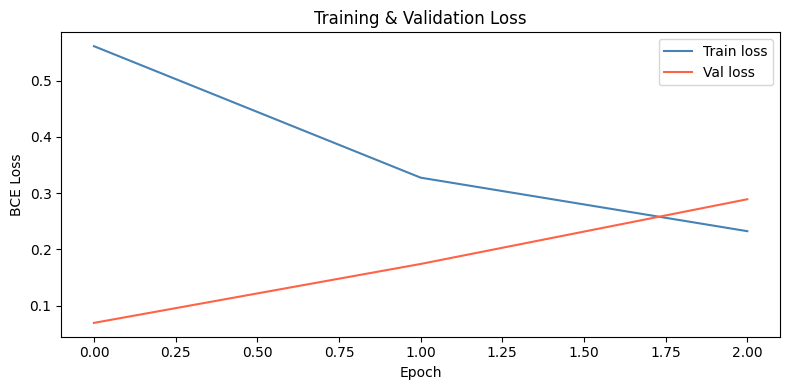

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss", color="steelblue")
plt.plot(val_losses,   label="Val loss",   color="tomato")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── Reload best checkpoint ────────────────────────────────────────────────────
hubert_lora.load_state_dict(torch.load("best_lora_adapter.pt", map_location=device))
model_best = DysarthriaClassifier(hubert_lora).to(device)
model_best.head.load_state_dict(torch.load("best_head.pt", map_location=device))
model_best.eval()

# FIX 6: threshold is selected ONCE here from the val PR curve.
#         It is NOT searched inside the training loop — that would give
#         an optimistically-biased val F1 (different best threshold each epoch).
val_probs, val_true = [], []
with torch.no_grad():
    for iv, am, lbl in val_loader:
        if iv is None:
            continue
        with autocast():
            logits = model_best(iv.to(device), am.to(device))
        val_probs.extend(torch.sigmoid(logits).cpu().float().numpy().flatten())
        val_true.extend(lbl.numpy().flatten())

val_probs = np.array(val_probs)
val_true  = np.array(val_true)

prec, rec, thresh = precision_recall_curve(val_true, val_probs)
f1s      = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
best_idx = int(np.argmax(f1s))
best_thr = float(thresh[best_idx])

print(f"Optimal threshold : {best_thr:.4f}  (val F1 = {f1s[best_idx]:.4f})")
print("This threshold will be applied to the held-out test set.")

plt.figure(figsize=(8, 4))
plt.plot(thresh, f1s, color="steelblue")
plt.axvline(best_thr, color="red", linestyle="--", label=f"Optimal = {best_thr:.3f}")
plt.xlabel("Threshold"); plt.ylabel("F1 Score")
plt.title("Threshold Sweep — Validation Set  (selected once, post-training)")
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
model_best.eval()
test_probs, test_true = [], []

with torch.no_grad():
    for iv, am, lbl in test_loader:
        if iv is None: continue
        with autocast():
            logits = model_best(iv.to(device), am.to(device))
        test_probs.extend(torch.sigmoid(logits).cpu().float().numpy().flatten())
        test_true.extend(lbl.numpy().flatten())

test_preds = (np.array(test_probs) > best_thr).astype(int)
test_true  = np.array(test_true)

print(f"Threshold : {best_thr:.4f}")
print(f"Accuracy  : {accuracy_score(test_true, test_preds):.4f}\n")
print(classification_report(test_true, test_preds,
      target_names=["Control", "Dysarthric"], zero_division=0))

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Dysarthric"],
            yticklabels=["Control", "Dysarthric"])
plt.ylabel("True"); plt.xlabel("Predicted")
plt.title("Confusion Matrix — Test Set (Speaker-Independent)")
plt.tight_layout(); plt.show()


In [ ]:
SEVERITY = {"M01": "Severe-dys", "M05": "Mild-dys", "FC01": "Control", "MC04": "Control"}

res = {}
model_best.eval()

with torch.no_grad():
    for path, true_label in zip(X_test, y_test):
        spk = get_speaker(path)
        sev = SEVERITY.get(spk, "Unknown")
        audio = preprocess_audio(path)
        if audio is None:
            continue
        audio = np.array(audio, dtype=np.float32)
        enc = feature_extractor(audio, sampling_rate=SR, return_tensors="pt",
                                padding=True, return_attention_mask=True,
                                max_length=MAX_SAMPLES, truncation=True)
        iv = enc["input_values"].to(device)
        am = enc["attention_mask"].to(device)
        with autocast():
            logit = model_best(iv, am).item()
        pred = int(torch.sigmoid(torch.tensor(logit)).item() > best_thr)
        res.setdefault(sev, {"c": 0, "t": 0})
        res[sev]["t"] += 1
        res[sev]["c"] += int(pred == int(true_label))

print(f"{'Group':<14}  {'Acc':>6}  {'N':>5}")
print("-" * 28)
for sev, r in sorted(res.items()):
    print(f"{sev:<14}  {r['c']/r['t']:>6.3f}  {r['t']:>5}")


In [ ]:
if device.type == "cuda":
    alloc  = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved()  / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM allocated : {alloc:.2f} GB")
    print(f"VRAM reserved  : {reserv:.2f} GB")
    print(f"VRAM total     : {total:.2f} GB")
    print(f"VRAM free      : {total - reserv:.2f} GB")


In [11]:
import json

meta = {
    "backbone"      : "facebook/hubert-base-ls960",
    "lora_rank"     : 4,
    "lora_alpha"    : 8,
    "lora_targets"  : ["q_proj", "v_proj"],
    "best_threshold": best_thr,
    "test_speakers" : list(TEST_SPEAKERS),
    "val_speakers"  : list(VAL_SPEAKERS),
}

torch.save(hubert_lora.state_dict(), "dysarthria_lora_final.pt")
torch.save(model_best.head.state_dict(), "dysarthria_head_final.pt")

with open("model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved: dysarthria_lora_final.pt")
print("Saved: dysarthria_head_final.pt")
print("Saved: model_meta.json")
print(json.dumps(meta, indent=2))


NameError: name 'best_thr' is not defined